In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
 
from langchain_huggingface import HuggingFaceEmbeddings 
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

import requests
import math
import os
import json
from tavily import TavilyClient
load_dotenv()
llm = ChatGroq(model="qwen/qwen3.6-27b", temperature=0.5, max_tokens=500)
clint = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
@tool
def search_tool(query:str)->str:
    """Expart in extrxt information about the topic provided"""

    result = clint.search(
        max_results=5,
       
        topic="general",
        search_depth="advanced",
        query=query)

    return json.dumps(result)

@tool
def Calculator(expression:str)->str:
    """Usful for simple math calculation Input should be a  valid math expression . 
    Example:2+2,math.sqrt(16),10*5"""

    try:
        allowed = {
            "math":math,
            "abs":abs,
            "round":round,
            "min":min,
            "max":max,
            "sum":sum
        }
        result = eval(expression,{"__builtines__":{}},allowed)
        return str(result)
    except expression as e:
        print(e)
import os
import requests
@tool
def get_stock_price(symbol: str) -> dict:
    """Fetch latest stock price for a given ticker symbol using Alpha Vantage."""
    api_key = os.getenv("ALPHA_VANTAGE_API_KEY")
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={api_key}"
    response = requests.get(url)
    return response.json()
import requests
from dotenv import load_dotenv
import os

load_dotenv()
@tool
def get_current_weather(city,units="metric"):
   
    """
    Fetch current weather for a given city using OpenWeatherMap API.

    Args:
        city (str): City name, e.g. "Dhaka" or "Dhaka,BD"
        units (str): "metric" (Celsius), "imperial" (Fahrenheit), or "standard" (Kelvin)

    Returns:
        dict: Parsed weather data, or None if the request failed
    """

    api_key = os.getenv("OPENWEATHER_API_KEY")
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "q": city,
        "appid": api_key,
        "units": units
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        return {
            "city": data["name"],
            "country": data["sys"]["country"],
            "temperature": data["main"]["temp"],
            "feels_like": data["main"]["feels_like"],
            "humidity": data["main"]["humidity"],
            "pressure": data["main"]["pressure"],
            "weather": data["weather"][0]["description"],
            "wind_speed": data["wind"]["speed"]
        }

    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
    except KeyError as e:
        print(f"Unexpected response format, missing key: {e}")

    return None

tools = [search_tool,Calculator,get_stock_price,get_current_weather]
llm_with_tools = llm.bind_tools(tools=tools)
class chatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
def chatbot(state: chatState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)    
graph = StateGraph(chatState)
graph.add_node("chatbot",chatbot)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chatbot")
graph.add_conditional_edges("chatbot",tools_condition)
graph.add_edge("tools","chatbot")
graph.add_edge("chatbot",END)

wf = graph.compile()
wf
init = {
    "messages":[HumanMessage(content="what is the stoke price in BMW? today")]
}
result = wf.invoke(init)
print(result['messages'][-1].content)

while True:
    print("Press EXIT to return.")
    user_input = input("Enter the query:")
    if user_input.lower()=="exit":
        print("Good bye")
        break
    else:
        init = {
            "messages":user_input
        }
        result = wf.invoke(init)
        print("AI:",result["messages"][-1].content)    



Press EXIT to return.
AI: The current weather in Dhaka is overcast clouds with a temperature of approximately **28°C** (feels like 34°C). The humidity is quite high at 89%, and the wind speed is around 1.54 m/s.
Press EXIT to return.


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `qwen/qwen3.6-27b` in organization `org_01kqvjnfv9etbbn09za3h7f9zh` service tier `on_demand` on output tokens per minute (OTPM): Limit 1000, Used 524, Requested 500. Please try again in 1.44s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
 
from langchain_huggingface import HuggingFaceEmbeddings 
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

import requests
import math
import os
import json
from tavily import TavilyClient

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS


load_dotenv()

data_path = "F:/newAgent/Data/The Prevalence of Sleep Disorders in College Students  Impact on Academic Performance.pdf"

loader = PyPDFLoader(file_path=data_path)

data = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000,chunk_overlap = 200)
chunks = splitter.split_documents(data)
embedding = HuggingFaceEmbeddings(
    model = "sentence-transformers/all-MiniLM-L6-v2"
)
vector_store = FAISS.from_documents(chunks,embedding)
vector_store.save_local("faiss_index")
retriver = vector_store.as_retriever(search_type = "similarity",search_kwargs={"k":4})



@tool
def rag_tool(query:str)->str:
    """
    Retriver relevent information from the PDF documents.
    use the tool the user asks factual or conneceptual question that may be answered the stored PDF documents.

    ARGS:
        Query:the question or search query used to retraive PDF content.
    """
    document = retriver.invoke(query)
    if not document:
        return "NO relavent document information was found in the PDF"
    formatted_documents =[]
    for index,document in enumerate(document,start=1):
        source = document.metadata.get("source","unknown")
        page = document.metadata.get("page","unknown")

        formatted_documents.append(
            f"Document: {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"content:{document.page_content}"
        )
    return "\n\n".join(formatted_documents)    
            

llm = ChatGroq(model="qwen/qwen3.6-27b", temperature=0.5, max_tokens=1000)
tools = [rag_tool]
llm_with_tool = llm.bind_tools(tools=tools)
tool_node = ToolNode(tools)
class Chatstate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

def chat_node(state:Chatstate):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    responce = llm_with_tool.invoke(messages)
    return {"messages":[responce]}
graph = StateGraph(Chatstate)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)   

graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")
chatbot = graph.compile()




fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/Subtype': '/Type1', '/FontDescriptor': IndirectObject(118, 0, 2757761314064), '/BaseFont': '/GMHFMI+Futura-Book', '/Encoding': '/WinAnsiEncoding', '/Widths': [308, 0, 308, 570, 616, 616, 616, 616, 616, 616, 616, 616, 0, 616, 0, 0, 0, 0, 0, 0, 0, 699, 568, 717, 678, 534, 478, 820, 714, 239, 314, 0, 375, 896, 834, 862, 503, 0, 542, 559, 470, 685, 624, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 577, 0, 476, 577, 519, 274, 580, 528, 262, 0, 0, 227, 0, 528, 562, 577, 0, 335, 399, 240, 512, 463, 0, 0, 498], '/Type': '/Font', '/FirstChar': 44, '/LastChar': 121}, but is not installed. Consider installing fontTools if you encounter encoding problems.
fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/Subtype': '/Type1', '/FontDescriptor': IndirectObject(119, 0, 2757761314064), '/BaseFont': '/GMHFMJ+Futura-Heavy', '/Encoding': '/WinAnsiEncoding', '/Widths': [289, 0, 0, 0, 0, 0,

8

In [15]:
vector_store

In [20]:
from rich import print

In [21]:
print(rag_tool.invoke("What is sleeping desorder?"))

Document: 1
Source: F:/newAgent/Data/The Prevalence of Sleep Disorders in College Students  Impact on Academic Performance.pdf
Page: 6
content:16. American Academy of Sleep Medicine. Sleep disorders.
Available at: http://www.sleepeducation.com/Disorders.aspx. Ac-
cessed April 16, 2009.
17. Longstreth WT, Koepsell TD, Ton TG, Hendrickson AF,
van Belle G. The epidemiology of narcolepsy. Sleep. 2007;30:
13–26.
18. Kamdar BB, Kaplan KA, Kezirian EJ, Dement WC. The
impact of extended sleep on daytime alertness, vigilance, and mood.
Sleep Med. 2004;5:441–448.
19. Killgore WDS, William DS, Lipizzi EL, Kamimori GH,
Balkin TJ. Caffeine effects on risky decision making after 75
hours of sleep deprivation. Aviat Space Env Med. 2007;78:
957–962.
20. Smith C. Sleep states and memory processes in humans:
procedural versus declarative memory systems. Sleep Med Rev.
2001;5:491–506.
21. Alchanatis M, Zias N, Deligiorgis N, Amﬁlochoiu A,
Dionellis G, Orphanidou D. Sleep apnea-related cognitive deﬁcits
and intelligence: an implication of cognitive reserve theory.J Sleep
Res. 2005;14:69–75.

Document: 2
Source: F:/newAgent/Data/The Prevalence of Sleep Disorders in College Students  Impact on Academic Performance.pdf
Page: 1
content:contribute to deprivation. Many college students are older
adolescents and are still dealing with adolescent physiology
such as a biologically driven delayed sleep phase. 2 Accord-
ing to the National Sleep Foundation,3 59% of adults 18 to 29
years of age describe themselves as night-owls. Unable to fall
asleep earlier in the evening, they cannot get enough sleep if
they must get up early. In addition, sleep may be voluntar-
ily sacriﬁced due to social factors or involuntarily curtailed
because of living in a noisy residence hall or apartment. A
typical coping technique for dealing with sleep deprivation
Dr Gaultney is with the Department of Psychology at University
of North Carolina at Charlotte in Charlotte, North Carolina.
Copyright © 2010 Taylor & Francis Group, LLC
is to attempt to make up for lost sleep by increasing sleep on
the weekends, a practice that actually worsens the problem.4
Another potential source of EDS that has been less thor-

Document: 3
Source: F:/newAgent/Data/The Prevalence of Sleep Disorders in College Students  Impact on Academic Performance.pdf
Page: 1
content:is to attempt to make up for lost sleep by increasing sleep on
the weekends, a practice that actually worsens the problem.4
Another potential source of EDS that has been less thor-
oughly examined in this population, however, is untreated
sleep disorders, which may be underdiagnosed among col-
lege students. The International Classiﬁcation of Sleep Dis-
orders5 categorizes 3 types of sleep disorders: dyssomnias
(which may produce EDS), parasomnias (which usually are
not associated with EDS), and medical/psychological disor-
ders. The ﬁrst 2 categories are primary disorders of sleep,
whereas the third category includes conditions that are often
associated with disrupted sleep.
The consequences of sleep problems—whether due to in-
sufﬁcient sleep or an untreated sleep disorder—can be se-
rious. Sleep problems have been associated with deﬁcits
in attention and academic performance, 6 drowsy driving,7
risk-taking behavior and depression, 8 impaired social rela-

Document: 4
Source: F:/newAgent/Data/The Prevalence of Sleep Disorders in College Students  Impact on Academic Performance.pdf
Page: 6
content:tions for restless legs syndrome in pregnancy. J Obstet Gynaecol .
2008;30:505–507.
27. Bentley A, Rosman KD, Mitchell D. Gender differences in
the presentation of subjects with restless legs syndrome.Sleep Med.
2006;7:37–41.
28. Liu X. Sleep and adolescent suicidal behavior. Sleep.
2004;27:1351–1358.
29. Levin R, Fireman G. Nightmare prevalence, nightmare
distress, and self-reported psychological disturbance. Sleep.
2002;25:205–212.
30. Kamdar BB, Kaplan KA, Kezirian EF, Dement WC. The
impact of extended sleep on daytime alertness, vigilan

In [47]:
llm = ChatGroq(model="qwen/qwen3.6-27b", temperature=0.5, max_tokens=1000)

In [48]:
tools = [rag_tool]
llm_with_tool = llm.bind_tools(tools=tools)

In [49]:
tool_node = ToolNode(tools)

In [50]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'rag_tool': StructuredTool(name='rag_tool', description='Retriver relevent information from the PDF documents.\nuse the tool the user asks factual or conneceptual question that may be answered the stored PDF documents.\n\nARGS:\n    Query:the question or search query used to retraive PDF content.', args_schema=<class 'langchain_core.utils.pydantic.rag_tool'>, func=<function rag_tool at 0x000002825024D9E0>)}, _injected_args={'rag_tool': _InjectedArgs(state={}, store=None, runtime=None, all_injected_keys=set(), _optional_state_args=set())}, _handle_tool_errors=<function _default_handle_tool_errors at 0x000002827FCC59E0>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

In [51]:
class Chatstate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

def chat_node(state:Chatstate):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    responce = llm_with_tool.invoke(messages)
    return {"messages":[responce]}
graph = StateGraph(Chatstate)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)   

graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")
chatbot = graph.compile()


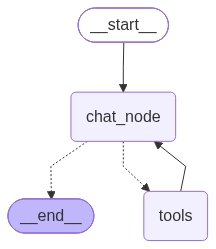

In [52]:
chatbot

In [56]:
init = {
    "messages": [HumanMessage(content="What is sleeping disorder")]  # Wrapped in a list
}
res = chatbot.invoke(init)
print(res['messages'][-1].content)

Based on the provided documents, a **sleeping disorder** is a condition that affects the quality, timing, and 
amount of a person's sleep.

According to the **International Classification of Sleep Disorders**, these disorders are categorized into three 
main types:

1.  **Dyssomnias**: These are primary disorders of sleep that may produce **Excessive Daytime Sleepiness (EDS)**.
2.  **Parasomnias**: These are primary disorders of sleep that are usually **not** associated with Excessive 
Daytime Sleepiness.
3.  **Medical/Psychological Disorders**: These are conditions often associated with disrupted sleep, which are 
secondary to other medical or psychological issues.

**Common Examples:**
The documents specifically mention the following disorders:
*   **Insomnia**: Difficulty falling or staying asleep.
*   **Narcolepsy**: A disorder involving excessive daytime sleepiness.
*   **RLS/PLMD**: Restless Legs Syndrome and Periodic Limb Movement

In [55]:
ai_message = res['messages'][-1]

# Check if reasoning content exists
reasoning = ai_message.additional_kwargs.get('reasoning_content', '')
print("Reasoning:", reasoning)

# Check standard content
print("Content:", ai_message.content)

Reasoning: The user is asking for the definition or explanation of "sleeping disorder" based on the provided text.

1.  **Analyze the Request:** The user wants to know "What is sleeping disorder".
2.  **Scan the Retrieved Documents:**
    *   **Document 1 (Page 1):** Mentions the "International Classification of Sleep Disorders" categorizes 3 
types:
        *   **Dyssomnias:** May produce Excessive Daytime Sleepiness (EDS).
        *   **Parasomnias:** Usually not associated with EDS.
        *   **Medical/Psychological disorders:** Conditions often associated with disrupted sleep.
        *   It notes that the first two are primary disorders of sleep, while the third category includes 
conditions associated with disrupted sleep.
    *   **Document 2 (Page 2):** Mentions specific examples like narcolepsy, insomnia, and RLS/PLMD (Restless Legs 
Syndrome/Periodic Limb Movement Disorder).
    *   **Document 4 (Page 1):** Discusses causes like "insufficient sleep" vs "untreated sleep disorders". It 
mentions biological factors (delayed sleep phase) and environmental factors (noisy residence hall) contributing to 
sleep deprivation, but distinguishes "untreated sleep disorders" as a potential source of EDS.

3.  **Synthesize the Answer:**
    *   **Definition/Categorization:** According to the International Classification of Sleep Disorders mentioned 
in the text, sleep disorders are categorized into three types:
        1.  **Dyssomnias:** Primary disorders of sleep that may produce Excessive Daytime Sleepiness (EDS).
        2.  **Parasomnias:** Primary disorders of sleep usually not associated with EDS.
        3.  **Medical/Psychological disorders:** Conditions often associated with disrupted sleep (secondary to 
other conditions).
    *   **Examples:** The text specifically lists narcolepsy, insomnia, and RLS/PLMD (Restless Legs 
Syndrome/Periodic Limb Movement Disorder) as commonly reported disorders in the studied population.
    *   **Impact:** They can lead to deficits in attention, academic performance, drowsy driving, risk-taking 
behavior, and depression.

4.  **Draft the Response:** Construct a clear explanation based on the synthesis.

    *   *Draft:* Based on the provided documents, sleep disorders are categorized by the International 
Classification of Sleep Disorders into three main types:
        1.  **Dyssomnias:** These are primary disorders of sleep that may result in Excessive Daytime Sleepiness 
(EDS).
        2.  **Parasomnias:** These are primary disorders of sleep that are usually not associated with EDS.
        3.  **Medical/Psychological Disorders:** This category includes conditions that are often associated with 
disrupted sleep.

        The documents also identify specific examples of these disorders, such as **narcolepsy**, **insomnia**, and
**RLS/PLMD** (Restless Legs Syndrome/Periodic Limb Movement Disorder). These disorders can lead to serious 
consequences, including deficits in attention, poor academic performance, drowsy driving, and depression.

5.  **Refine:** Ensure the tone is objective and directly answers the prompt using only the provided text. The 
distinction between "insufficient sleep" (behavioral/environmental) and "sleep disorders" (medical/primary) is also
worth noting if relevant, but the core definition comes from the categorization list.

6.  **Final Polish:** Present the categories clearly.

    *   *Final Answer:* According to the International Classification of Sleep Disorders mentioned in the text, 
sleep disorders are categorized into three types:
        *   **Dyssomnias:** Primary disorders of sleep that may produce Excessive Daytime Sleepiness (EDS).
        *   **Parasomnias:** Primary disorders of sleep that are usually not associated with EDS.
        *   **Medical/Psychological disorders:** Conditions often associated with disrupted sleep.

        Specific examples of sleep disorders cited in the text include **narcolepsy**, **insomnia**, and 
**RLS/PLMD** (Res

Content:

In [39]:
last_message = res["messages"][-1]

# If content is empty, check if reasoning content was captured
if not last_message.content:
  print("Thinking/Reasoning:", last_message.additional_kwargs.get("reasoning_content"))
else:
  print("Content:", last_message.content)

Thinking/Reasoning: The user is asking for a definition of "sleeping disorder".
I have retrieved information from a document titled "The Prevalence of Sleep Disorders in College Students Impact 
on Academic Performance.pdf".
The document mentions the International Classification of Sleep Disorders categorizes 3 types of sleep disorders:
1. Dyssomnias (which may produce Excessive Daytime Sleepiness - EDS).
2. Parasomnias (which usually are not associated with EDS).
3. Medical/Psychological disorders (conditions often associated with disrupted sleep).

It also lists specific disorders found in the study:
- OSA (Obstructive Sleep Apnea)
- Insomnia
- Narcolepsy
- RLS/PLMD (Restless Legs Syndrome/Periodic Limb Movement Disorder)
- CRDs (Circadian Rhythm Disorders)
- Sleepwalking
- Nightmares
- Affective Disorder
- SSM (Sleep State Misperception)
- Hypersomnia

I should synthesize this information to answer the user's question.

Plan:
1.  Define sleep disorders based on the provided text (referencing the International Classification).
2.  List the specific types mentioned in the text (Dyssomnias, Parasomnias, Medical/Psychological disorders).
3.  Give examples of specific disorders mentioned (Insomnia, Narcolepsy, Sleep Apnea, etc.).
4.  Mention the consequences briefly (EDS, academic performance deficits, etc.) to provide context.

The retrieved text explicitly categorizes them into 3 types. I will use that structure.

Answer construction:
Based on the provided documents, sleep disorders are categorized by the International Classification of Sleep 
Disorders into three main types:
1.  **Dyssomnias:** Disorders that may produce Excessive Daytime Sleepiness (EDS).
2.  **Parasomnias:** Disorders that usually are not associated with EDS.
3.  **Medical/Psychological Disorders:** Conditions that are often associated with disrupted sleep.

Specific examples of sleep disorders mentioned in the text include:
*   **Insomnia:** Difficulty falling or staying asleep.
*   **Narcolepsy:** A disorder causing excessive daytime sleepiness.
*   **OSA (Obstructive Sleep Apnea):** Breathing interruptions during sleep.
*   **RLS

In [49]:
from langchain_huggingface import HuggingFaceEmbeddings 
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain.messages import HumanMessage,AIMessage
from langchain_groq import ChatGroq
import requests
import math
import os
import json
from tavily import TavilyClient
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
load_dotenv()
llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0.5, max_tokens=900)
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]
def chatt_node(state:ChatState):   
    decision = interrupt({
        "type":"approval",
        "reason":"Model is about to answer a user question.",
        "question":state["messages"][-1].content,
        "instruction":"approve this question? Yes/No"
    }) 
    if decision["approved"]=="no":
        return{"messages":[AIMessage(content="not approve")]}
    else:
        responce = llm.invoke(state["messages"])
        return {"messages":[responce]}
builder = StateGraph(ChatState)
builder.add_node("chat",chatt_node)
builder.add_edge(START,"chat")
builder.add_edge("chat",END)

checkpointer = MemorySaver()
app = builder.compile(checkpointer=checkpointer)
cong = {"configurable":{"thread_id":1}}
init = {

"messages":[("user","Ecplain the greadient descent in very simple Teram")]

}

result = app.invoke(init,config=cong)
messages = result['__interrupt__'][0].value
user_inpout = input(f"\n Backend messages = {messages}\n approve This question(y/n):")


final = app.invoke(
    Command(resume={"approved":user_inpout}),
    config=cong
)
final

{'messages': [HumanMessage(content='Ecplain the greadient descent in very simple Teram', additional_kwargs={}, response_metadata={}, id='ad406d02-a13a-4562-b9de-94292cae2c16'),
  AIMessage(content='not approve', additional_kwargs={}, response_metadata={}, id='265b34bf-c059-4ba1-9943-7c2e70aa75de', tool_calls=[], invalid_tool_calls=[])]}

In [40]:
builder = StateGraph(ChatState)
builder.add_node("chat",chatt_node)
builder.add_edge(START,"chat")
builder.add_edge("chat",END)

checkpointer = MemorySaver()
app = builder.compile(checkpointer=checkpointer)


In [41]:
cong = {"configurable":{"thread_id":1}}

In [42]:
init = {

"messages":[("user","Ecplain the greadient descent in very simple Teram")]

}

result = app.invoke(init,config=cong)
result

{'messages': [HumanMessage(content='Ecplain the greadient descent in very simple Teram', additional_kwargs={}, response_metadata={}, id='0864867c-b812-4937-804f-9fe0672bd7fd')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Ecplain the greadient descent in very simple Teram', 'instruction': 'approve this question? Yes/No'}, id='27d1cfb07f6f35c11fca739f78a2e3e1')]}

In [43]:
messages = result['__interrupt__'][0].value

In [45]:
user_inpout = input(f"\n Backend messages = {messages}\n approve This question(y/n):")


final = app.invoke(
    Command(resume={"approved":user_inpout}),
    config=cong
)
final

{'messages': [HumanMessage(content='Ecplain the greadient descent in very simple Teram', additional_kwargs={}, response_metadata={}, id='0864867c-b812-4937-804f-9fe0672bd7fd'),
  AIMessage(content="**Gradient Descent in Plain English**\n\nImagine you’re standing on a big, bumpy hill that’s covered in fog.  \nYou want to get to the lowest point (the valley), but you can’t see far ahead.\n\n1. **Take a Step Toward the Slope**  \n   You feel the slope under your feet.  \n   - If the ground tilts downwards, you step in that direction.  \n   - If it tilts upwards, you step the opposite way.\n\n2. **Keep Repeating**  \n   After each step, you check the slope again and step again.  \n   Each time you move a little farther down.\n\n3. **Stop When the Slope is Flat**  \n   When the ground feels level (no slope), you’ve reached the valley.\n\nThat’s basically **gradient descent**:\n\n| What you’re doing | What it means mathematically |\n|-------------------|------------------------------|\n| Fee

In [25]:
final

{'messages': [HumanMessage(content='Ecplain the greadient descent in very simple Teram', additional_kwargs={}, response_metadata={}, id='a19273b2-042b-4099-be43-e39583ae07f1'),
  AIMessage(content="### Gradient Descent – The “Walk‑Down‑the‑Hill” Trick\n\nThink of a landscape made of hills and valleys.  \nYou’re standing somewhere on that landscape and you want to reach the lowest point (the *valley*).  \nYou can’t see the whole map, but you can feel the slope right where you are.  \n**Gradient descent** is the rule that tells you how to walk downhill step by step.\n\n---\n\n#### 1. What is “the slope” (the *gradient*)?\n\n- In one dimension (just a single number `x`) the slope is the derivative `f'(x)`.  \n  - If `f'(x)` is positive → you’re on a rising slope → go left.  \n  - If `f'(x)` is negative → you’re on a falling slope → go right.  \n- In many dimensions (e.g., a vector `θ` of parameters) the gradient is a vector of partial derivatives:  \n  \\[\n  \\nabla f(\\theta) = \\left[\